# Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, f1_score,
)
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

In [2]:
# Features
X_train = pd.read_csv("../../../data/processed/splits/X_train.csv",
                      parse_dates=["Date"], index_col="Date")
X_val   = pd.read_csv("../../../data/processed/splits/X_val.csv",
                      parse_dates=["Date"], index_col="Date")
X_test  = pd.read_csv("../../../data/processed/splits/X_test.csv",
                      parse_dates=["Date"], index_col="Date")

# Classification targets
y_train = pd.read_csv("../../../data/processed/splits/y_train_clf.csv",
                      parse_dates=["Date"], index_col="Date").squeeze()
y_val   = pd.read_csv("../../../data/processed/splits/y_val_clf.csv",
                      parse_dates=["Date"], index_col="Date").squeeze()
y_test  = pd.read_csv("../../../data/processed/splits/y_test_clf.csv",
                      parse_dates=["Date"], index_col="Date").squeeze()

print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")

X_train : (1479, 69)
X_val   : (501, 69)
X_test  : (563, 69)


# Training Model

In [3]:
def evaluate_classifier(name, model, X, y, split_label="Validation", plot=True):
    y_pred = model.predict(X)

    acc     = accuracy_score(y, y_pred)
    f1_mac  = f1_score(y, y_pred, average='macro')
    f1_down = f1_score(y, y_pred, average=None, labels=[-1])[0]
    f1_up   = f1_score(y, y_pred, average=None, labels=[1])[0]

    print(f"  {name}  [{split_label}]")
    print(classification_report(y, y_pred,
          target_names=['Down(-1)', 'Side(0)', 'Up(1)']))

    if plot:
        cm   = confusion_matrix(y, y_pred, labels=[-1, 0, 1])
        disp = ConfusionMatrixDisplay(cm, display_labels=['Down', 'Side', 'Up'])
        disp.plot(cmap='Blues')
        plt.title(f'Confusion Matrix — {name} [{split_label}]')
        plt.tight_layout()
        plt.show()

    return {
        'Model': name, 'Split': split_label,
        'Accuracy': round(acc, 4),
        'F1 Macro': round(f1_mac, 4),
        'F1 Down':  round(f1_down, 4),
        'F1 Up':    round(f1_up, 4),
    }

In [4]:
rf_clf = RandomForestClassifier(
    n_estimators=400,
    max_depth=12,
    min_samples_leaf=5,
    min_samples_split=17,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
rf_clf.fit(X_train, y_train)
print("Random Forest Classifier trained")

Random Forest Classifier trained


# Evaluation


TRAIN METRICS (Overfitting check)
  RF Classifier (Baseline)  [Train]
              precision    recall  f1-score   support

    Down(-1)       0.97      0.99      0.98       375
     Side(0)       0.98      0.96      0.97       649
       Up(1)       0.96      0.98      0.97       455

    accuracy                           0.97      1479
   macro avg       0.97      0.97      0.97      1479
weighted avg       0.97      0.97      0.97      1479


VALIDATION EVALUATION
  RF Classifier (Baseline)  [Validation]
              precision    recall  f1-score   support

    Down(-1)       0.23      0.14      0.17       143
     Side(0)       0.40      0.72      0.51       203
       Up(1)       0.33      0.10      0.15       155

    accuracy                           0.36       501
   macro avg       0.32      0.32      0.28       501
weighted avg       0.33      0.36      0.30       501



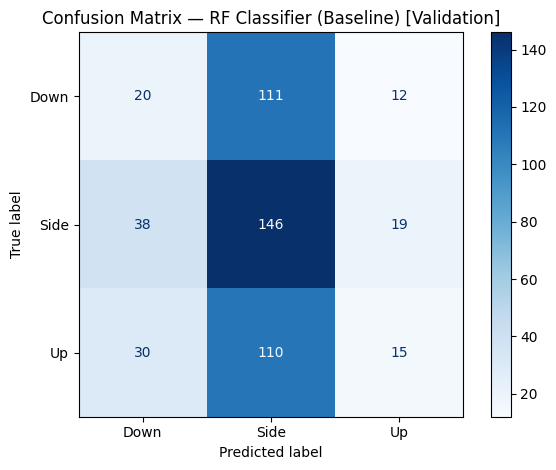


TEST SET EVALUATION
  RF Classifier (Baseline)  [Test]
              precision    recall  f1-score   support

    Down(-1)       0.26      0.17      0.21       120
     Side(0)       0.41      0.86      0.56       227
       Up(1)       0.75      0.03      0.05       216

    accuracy                           0.39       563
   macro avg       0.47      0.35      0.27       563
weighted avg       0.51      0.39      0.29       563



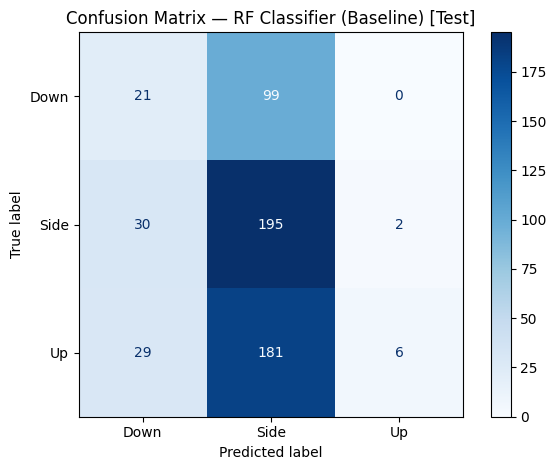

In [5]:
# Train Metrics (Overfitting check)
print("\nTRAIN METRICS (Overfitting check)")
res_train_base = evaluate_classifier(
    "RF Classifier (Baseline)", rf_clf, X_train, y_train,
    split_label="Train", plot=False
)

# Validation Evaluation
print("\nVALIDATION EVALUATION")
res_val_base = evaluate_classifier(
    "RF Classifier (Baseline)", rf_clf, X_val, y_val,
    split_label="Validation"
)

# Test Set Evaluation
print("\nTEST SET EVALUATION")
res_test_base = evaluate_classifier(
    "RF Classifier (Baseline)", rf_clf, X_test, y_test,
    split_label="Test"
)

# Hyperparameter Tuning

In [6]:
# Combine train + val for tuning (time-ordered, no shuffle)
X_tune = pd.concat([X_train, X_val])
y_tune = pd.concat([y_train, y_val])

tscv = TimeSeriesSplit(n_splits=5)

param_dist_clf = {
    'n_estimators':      [200, 300, 500],
    'max_depth':         [5, 8, 10, 15, None],
    'min_samples_leaf':  [5, 10, 20],
    'min_samples_split': [10, 20, 40],
    'max_features':      ['sqrt', 'log2'],
}

rf_clf_search = RandomizedSearchCV(
    RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    ),
    param_distributions=param_dist_clf,
    n_iter=30,
    cv=tscv,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
rf_clf_search.fit(X_tune, y_tune)

print(f"\nBest params : {rf_clf_search.best_params_}")
print(f"Best F1 Macro (CV): {rf_clf_search.best_score_:.4f}")

best_rf_clf = rf_clf_search.best_estimator_

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best params : {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 'log2', 'max_depth': 8}
Best F1 Macro (CV): 0.3393



>>> TRAIN METRICS — Tuned (Overfitting check)
  RF Classifier (Tuned)  [Train]
              precision    recall  f1-score   support

    Down(-1)       0.90      0.90      0.90       375
     Side(0)       0.92      0.89      0.90       649
       Up(1)       0.88      0.92      0.90       455

    accuracy                           0.90      1479
   macro avg       0.90      0.90      0.90      1479
weighted avg       0.90      0.90      0.90      1479


>>> VALIDATION EVALUATION — Tuned
  RF Classifier (Tuned)  [Validation]
              precision    recall  f1-score   support

    Down(-1)       0.94      0.99      0.96       143
     Side(0)       0.97      0.93      0.95       203
       Up(1)       0.94      0.95      0.95       155

    accuracy                           0.95       501
   macro avg       0.95      0.96      0.95       501
weighted avg       0.95      0.95      0.95       501



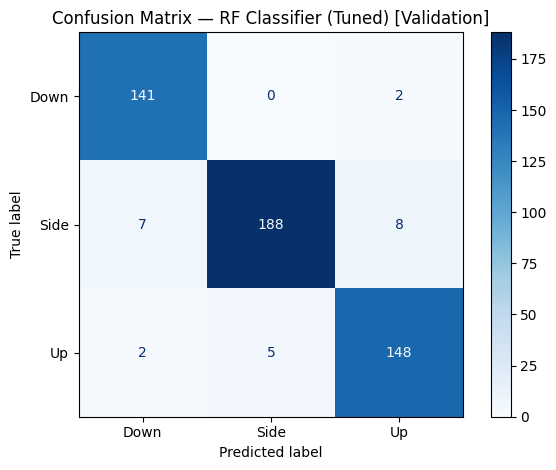


>>> TEST SET EVALUATION — Tuned
  RF Classifier (Tuned)  [Test]
              precision    recall  f1-score   support

    Down(-1)       0.21      0.27      0.24       120
     Side(0)       0.42      0.59      0.49       227
       Up(1)       0.46      0.19      0.27       216

    accuracy                           0.37       563
   macro avg       0.36      0.35      0.33       563
weighted avg       0.39      0.37      0.35       563



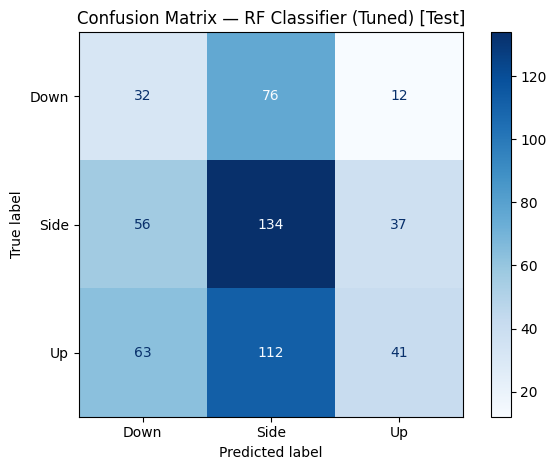

In [7]:
# ──  Tuned: TRAIN / VALIDATION / TEST
print("\n>>> TRAIN METRICS — Tuned (Overfitting check)")
res_train_tuned = evaluate_classifier(
    "RF Classifier (Tuned)", best_rf_clf, X_train, y_train,
    split_label="Train", plot=False
)

print("\n>>> VALIDATION EVALUATION — Tuned")
res_val_tuned = evaluate_classifier(
    "RF Classifier (Tuned)", best_rf_clf, X_val, y_val,
    split_label="Validation"
)

print("\n>>> TEST SET EVALUATION — Tuned")
res_test_tuned = evaluate_classifier(
    "RF Classifier (Tuned)", best_rf_clf, X_test, y_test,
    split_label="Test"
)

# Summary

In [8]:
all_results = pd.DataFrame([
    res_train_base, res_val_base, res_test_base,
    res_train_tuned, res_val_tuned, res_test_tuned,
])

print("\n=== Classification Summary ===")
print(all_results.to_string(index=False))


=== Classification Summary ===
                   Model      Split  Accuracy  F1 Macro  F1 Down  F1 Up
RF Classifier (Baseline)      Train    0.9716    0.9723   0.9789 0.9684
RF Classifier (Baseline) Validation    0.3613    0.2782   0.1732 0.1493
RF Classifier (Baseline)       Test    0.3943    0.2730   0.2100 0.0536
   RF Classifier (Tuned)      Train    0.8999    0.8993   0.8975 0.8968
   RF Classifier (Tuned) Validation    0.9521    0.9525   0.9625 0.9457
   RF Classifier (Tuned)       Test    0.3677    0.3308   0.2362 0.2680


# Feature Important


>>> FEATURE IMPORTANCE — Baseline


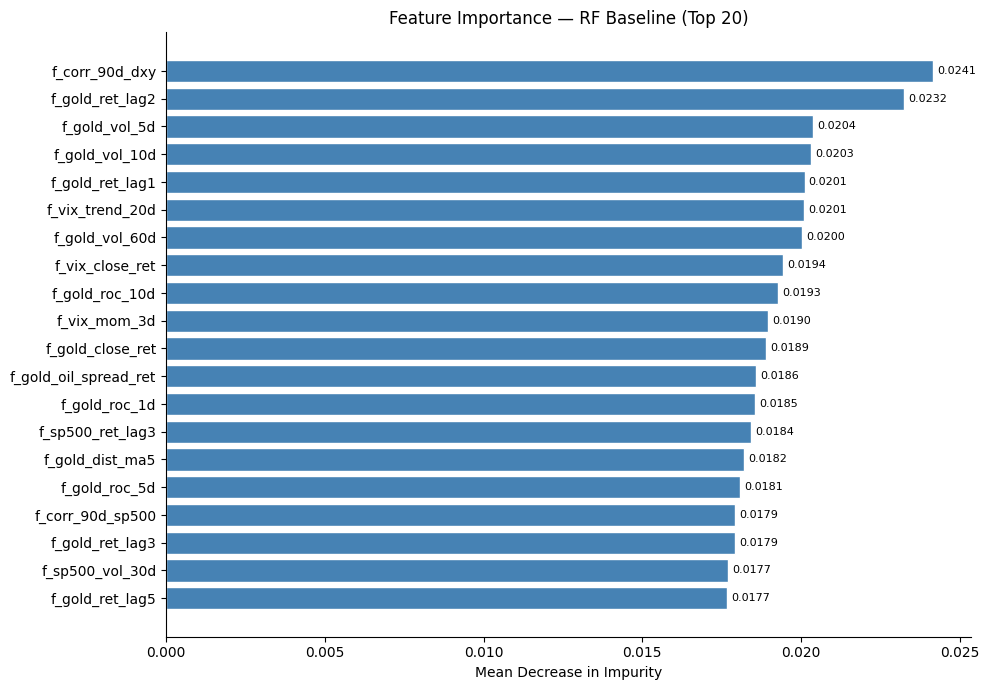


>>> FEATURE IMPORTANCE — Tuned


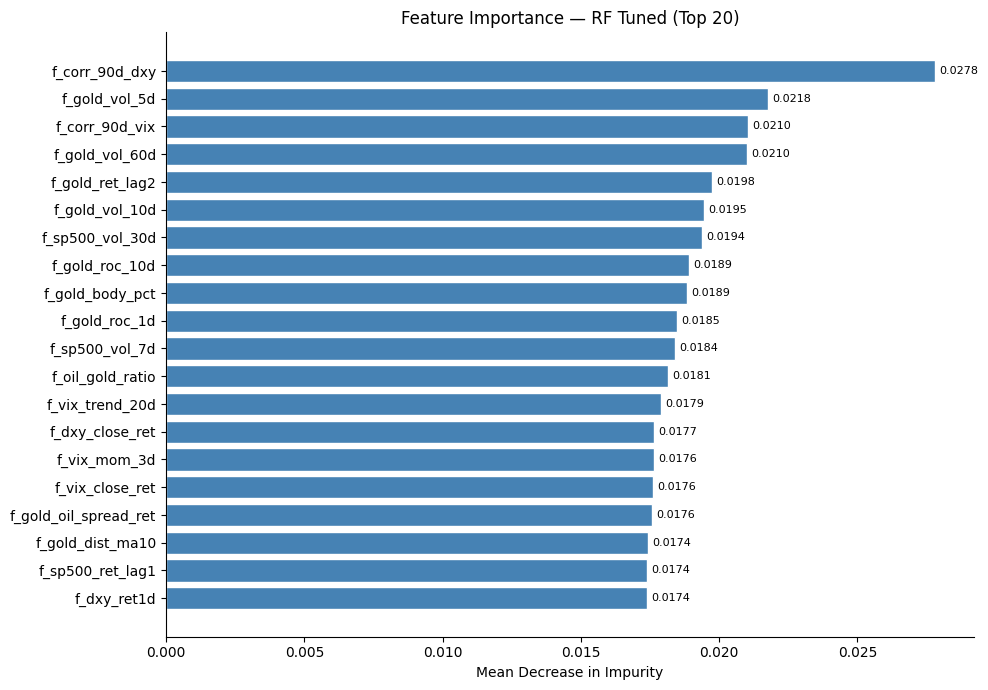

In [9]:
def plot_feature_importance(model, feature_names, title="Feature Importance", top_n=20):
    importances = model.feature_importances_
    indices     = np.argsort(importances)[::-1][:top_n]
    top_features = [feature_names[i] for i in indices]
    top_imp      = importances[indices]

    fig, ax = plt.subplots(figsize=(10, max(4, top_n * 0.35)))
    bars = ax.barh(top_features[::-1], top_imp[::-1], color='steelblue', edgecolor='white')
    ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=8)
    ax.set_xlabel("Mean Decrease in Impurity")
    ax.set_title(title)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()

    return pd.DataFrame({'Feature': top_features, 'Importance': top_imp})

print("\n>>> FEATURE IMPORTANCE — Baseline")
fi_base = plot_feature_importance(
    rf_clf, X_train.columns.tolist(),
    title="Feature Importance — RF Baseline (Top 20)"
)

print("\n>>> FEATURE IMPORTANCE — Tuned")
fi_tuned = plot_feature_importance(
    best_rf_clf, X_train.columns.tolist(),
    title="Feature Importance — RF Tuned (Top 20)"
)

# Visualization

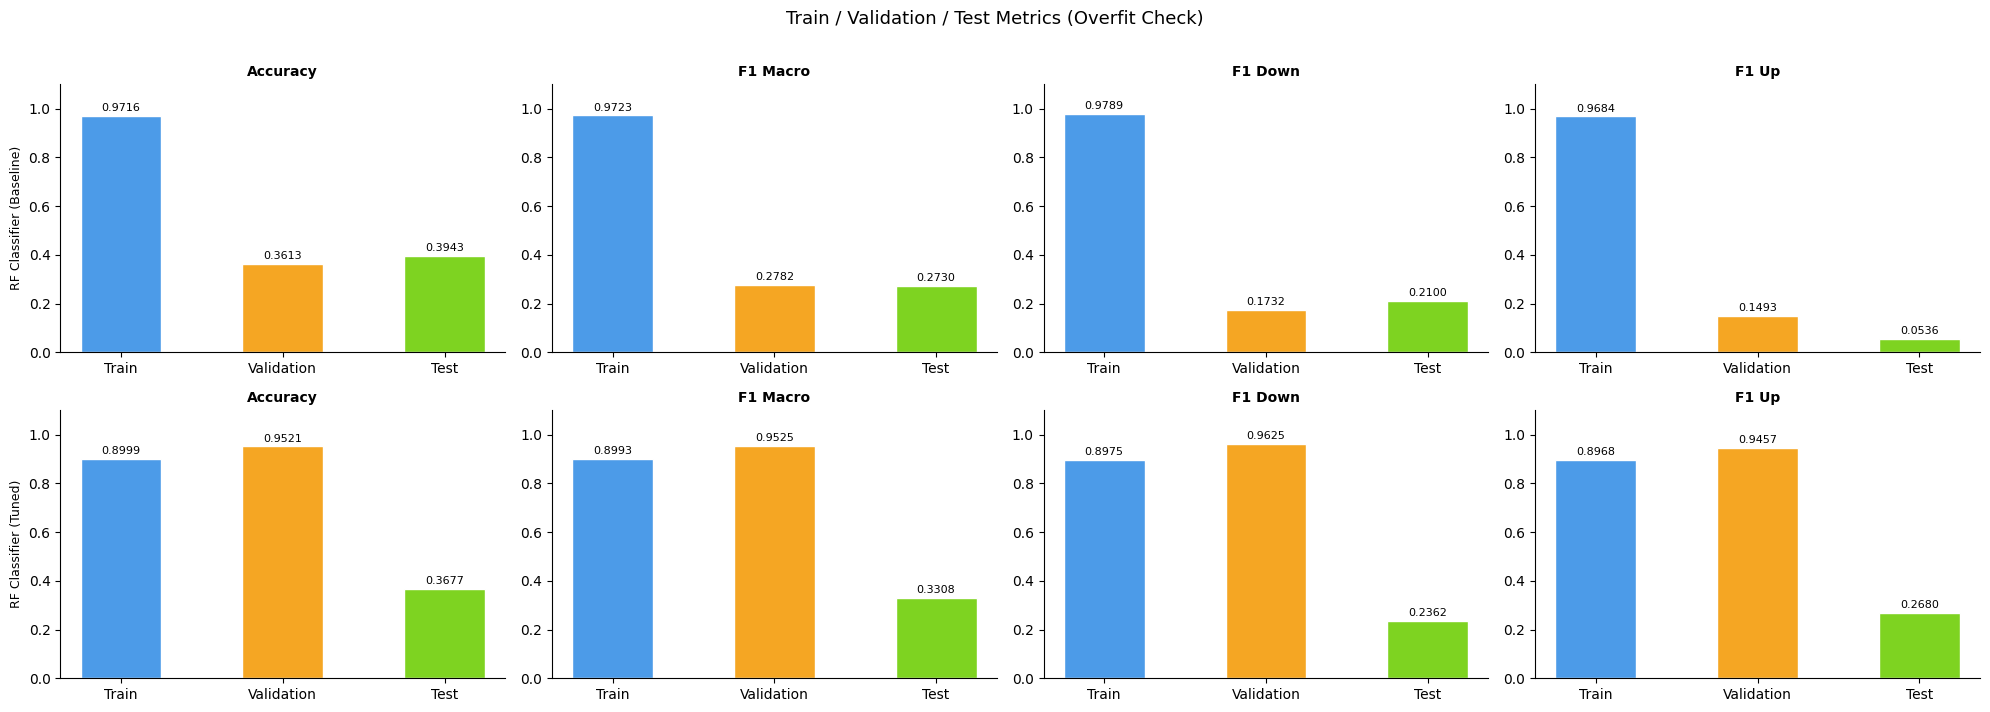

In [10]:
# Overfit gap + F1 per split
def plot_overfit_summary(results_df):
    models   = results_df['Model'].unique()
    metrics  = ['Accuracy', 'F1 Macro', 'F1 Down', 'F1 Up']
    splits   = ['Train', 'Validation', 'Test']
    colors   = {'Train': '#4C9BE8', 'Validation': '#F5A623', 'Test': '#7ED321'}

    fig, axes = plt.subplots(
        len(models), len(metrics),
        figsize=(5 * len(metrics), 3.5 * len(models)),
        sharey=False,
    )
    if len(models) == 1:
        axes = axes[np.newaxis, :]

    for row, model in enumerate(models):
        sub = results_df[results_df['Model'] == model]
        for col, metric in enumerate(metrics):
            ax = axes[row, col]
            vals  = [sub.loc[sub['Split'] == s, metric].values[0]
                     if s in sub['Split'].values else np.nan for s in splits]
            bars  = ax.bar(splits, vals,
                           color=[colors[s] for s in splits], width=0.5, edgecolor='white')
            ax.bar_label(bars, fmt='%.4f', fontsize=8, padding=2)
            ax.set_ylim(0, 1.1)
            ax.set_title(f"{metric}", fontsize=10, fontweight='bold')
            ax.spines[['top', 'right']].set_visible(False)
            if col == 0:
                ax.set_ylabel(model, fontsize=9)

    fig.suptitle("Train / Validation / Test Metrics (Overfit Check)", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

plot_overfit_summary(all_results)

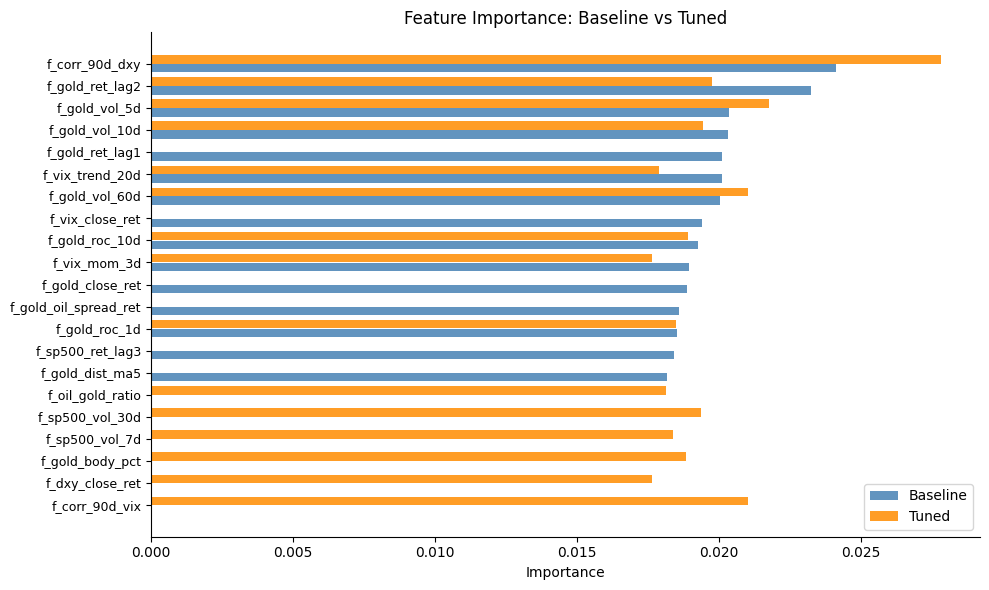

In [11]:
# Feature importance side-by-side
def plot_fi_comparison(fi_base, fi_tuned, top_n=15):
    common = pd.merge(
        fi_base.head(top_n).rename(columns={'Importance': 'Baseline'}),
        fi_tuned.head(top_n).rename(columns={'Importance': 'Tuned'}),
        on='Feature', how='outer',
    ).fillna(0).sort_values('Baseline', ascending=True)

    fig, ax = plt.subplots(figsize=(10, max(5, top_n * 0.4)))
    y = np.arange(len(common))
    ax.barh(y - 0.2, common['Baseline'], 0.38, label='Baseline', color='steelblue', alpha=0.85)
    ax.barh(y + 0.2, common['Tuned'],    0.38, label='Tuned',    color='darkorange', alpha=0.85)
    ax.set_yticks(y)
    ax.set_yticklabels(common['Feature'], fontsize=9)
    ax.set_xlabel("Importance")
    ax.set_title("Feature Importance: Baseline vs Tuned")
    ax.legend()
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()

plot_fi_comparison(fi_base, fi_tuned)

In [14]:
import os

# %% [markdown]
# # Export Predictions
# %%
def export_predictions(model, X, y, threshold=0.34, output_filename="rf_predictions.csv"):
    """
    สร้าง DataFrame และส่งออกผลลัพธ์การทำนายพร้อมเงื่อนไข Confidence Threshold
    """
    # ทำนายผลคลาสและดึงค่าความน่าจะเป็น
    pred_raw = model.predict(X)
    pred_proba = model.predict_proba(X)
    
    # ตรวจสอบ index ของคลาสเพื่อให้ map probability ได้ถูกต้อง (-1, 0, 1)
    classes = model.classes_
    idx_down = np.where(classes == -1)[0][0]
    idx_side = np.where(classes == 0)[0][0]
    idx_up   = np.where(classes == 1)[0][0]
    
    # แยก Probability ของแต่ละคลาส
    proba_down = pred_proba[:, idx_down]
    proba_side = pred_proba[:, idx_side]
    proba_up   = pred_proba[:, idx_up]
    
    # หาค่าความน่าจะเป็นที่สูงที่สุด
    max_proba = np.max(pred_proba, axis=1)
    
    # สร้างเงื่อนไข Threshold
    # ถ้า max_proba >= threshold ให้ signal_active เป็น 1, นอกนั้นเป็น 0
    signal_active = (max_proba >= threshold).astype(int)
    
    # สร้าง pred_direction_thr: ถ้ายืนยันสัญญาณให้ใช้ค่า pred_raw ถ้าไม่ให้เป็น 0 (Side)
    pred_thr = np.where(signal_active == 1, pred_raw, 0)
    
    # สร้าง DataFrame
    df_export = pd.DataFrame({
        'Date': X.index,
        'actual_direction': y.values,
        'pred_direction_raw': pred_raw,
        'pred_direction_thr': pred_thr,
        'confidence_threshold': threshold,
        'max_proba': max_proba,
        'proba_down': proba_down,
        'proba_side': proba_side,
        'proba_up': proba_up,
        'signal_active': signal_active
    })
    
    # จัดรูปแบบทศนิยม (ตัวเลือกเพิ่มเติมเพื่อให้เหมือนตัวอย่างเป๊ะๆ)
    # แต่ปกติเวลา export เป็น csv ค่าจะไปเต็มๆ อยู่แล้ว
    
    # ตรวจสอบและสร้างโฟลเดอร์สำหรับจัดเก็บ
    output_dir = "../../../data/processed/predictions"
    os.makedirs(output_dir, exist_ok=True)
    output_path = os.path.join(output_dir, output_filename)
    
    # บันทึกเป็นไฟล์ CSV
    df_export.to_csv(output_path, index=False)
    print(f"\nExported predictions to: {output_path}")
    
    return df_export

# รันฟังก์ชันด้วยโมเดลที่ Tune แล้ว (best_rf_clf) กับข้อมูล Test Set
df_results = export_predictions(
    model=best_rf_clf, 
    X=X_test, 
    y=y_test, 
    threshold=0.34, 
    output_filename="rf_clf.csv"
)

# แสดงตัวอย่างผลลัพธ์
display(df_results.head(15))


Exported predictions to: ../../../data/processed/predictions/rf_clf.csv


,Date,actual_direction,pred_direction_raw,pred_direction_thr,confidence_threshold,max_proba,proba_down,proba_side,proba_up,signal_active
0,2024-01-02,-1,-1,-1,0.34,0.342065,0.342065,0.320933,0.337002,1
1,2024-01-03,1,1,1,0.34,0.348179,0.315432,0.336388,0.348179,1
2,2024-01-04,0,0,0,0.34,0.365532,0.320001,0.365532,0.314467,1
3,2024-01-05,-1,0,0,0.34,0.338255,0.333506,0.338255,0.328239,0
4,2024-01-08,0,0,0,0.34,0.362639,0.312981,0.362639,0.324380,1
5,2024-01-09,0,0,0,0.34,0.355211,0.321994,0.355211,0.322795,1
6,2024-01-10,-1,0,0,0.34,0.367573,0.293879,0.367573,0.338548,1
7,2024-01-11,1,1,1,0.34,0.377619,0.264028,0.358353,0.377619,1
8,2024-01-12,-1,0,0,0.34,0.349939,0.322932,0.349939,0.327129,1
9,2024-01-16,-1,0,0,0.34,0.388828,0.266398,0.388828,0.344774,1


In [13]:
# # ============================================================
# # RF OUTPUT EXTRACTION — Test Set
# # Model  : Tuned Random Forest (best_rf_clf)
# # Output : pred_class (-1/0/1) + prob_down + prob_side + prob_up
# # ============================================================

# import pandas as pd
# import numpy as np
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import accuracy_score, f1_score, classification_report
# from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

# # ============================================================
# # 0: LOAD DATA
# # ============================================================
# print("=" * 60)
# print("0: LOAD DATA")
# print("=" * 60)

# BASE = "../../../data/processed/splits/"

# X_train = pd.read_csv(BASE + "X_train.csv", parse_dates=["Date"], index_col="Date")
# X_val   = pd.read_csv(BASE + "X_val.csv",   parse_dates=["Date"], index_col="Date")
# X_test  = pd.read_csv(BASE + "X_test.csv",  parse_dates=["Date"], index_col="Date")

# y_train = pd.read_csv(BASE + "y_train_clf.csv", parse_dates=["Date"], index_col="Date").squeeze()
# y_val   = pd.read_csv(BASE + "y_val_clf.csv",   parse_dates=["Date"], index_col="Date").squeeze()
# y_test  = pd.read_csv(BASE + "y_test_clf.csv",  parse_dates=["Date"], index_col="Date").squeeze()

# print(f"  X_train : {X_train.shape}")
# print(f"  X_val   : {X_val.shape}")
# print(f"  X_test  : {X_test.shape}")

# # ============================================================
# # 1: TRAIN TUNED RF
# #    (Replicate hyperparameter tuning จากโค้ดเดิม)
# # ============================================================
# print("\n" + "=" * 60)
# print("1: HYPERPARAMETER TUNING (Tuned RF)")
# print("=" * 60)

# X_tune = pd.concat([X_train, X_val])
# y_tune = pd.concat([y_train, y_val])

# tscv = TimeSeriesSplit(n_splits=5)

# param_dist_clf = {
#     "n_estimators"     : [200, 300, 500],
#     "max_depth"        : [5, 8, 10, 15, None],
#     "min_samples_leaf" : [5, 10, 20],
#     "min_samples_split": [10, 20, 40],
#     "max_features"     : ["sqrt", "log2"],
# }

# rf_search = RandomizedSearchCV(
#     RandomForestClassifier(
#         class_weight="balanced",
#         random_state=42,
#         n_jobs=-1,
#     ),
#     param_distributions=param_dist_clf,
#     n_iter=30,
#     cv=tscv,
#     scoring="f1_macro",
#     random_state=42,
#     n_jobs=-1,
#     verbose=1,
# )
# rf_search.fit(X_tune, y_tune)

# print(f"\n  Best params   : {rf_search.best_params_}")
# print(f"  Best F1 Macro : {rf_search.best_score_:.4f}")

# best_rf = rf_search.best_estimator_

# # ============================================================
# # 2: PREDICT ON TEST SET
# # ============================================================
# print("\n" + "=" * 60)
# print("2: PREDICT ON TEST SET")
# print("=" * 60)

# # classes_ order = [-1, 0, 1]  (sklearn sorts ascending)
# classes = best_rf.classes_   # array([-1,  0,  1])
# print(f"  Model classes : {classes}")

# pred_class = best_rf.predict(X_test)           # shape (n,)
# pred_proba = best_rf.predict_proba(X_test)     # shape (n, 3)

# # Map probability columns by class order
# idx_down = list(classes).index(-1)
# idx_side = list(classes).index(0)
# idx_up   = list(classes).index(1)

# prob_down = pred_proba[:, idx_down]
# prob_side = pred_proba[:, idx_side]
# prob_up   = pred_proba[:, idx_up]

# # ============================================================
# # 3: BUILD OUTPUT DataFrame
# # ============================================================
# print("\n" + "=" * 60)
# print("3: BUILD OUTPUT")
# print("=" * 60)

# df_out = pd.DataFrame({
#     "actual_class": y_test.values,
#     "pred_class"  : pred_class,
#     "prob_down"   : np.round(prob_down, 6),
#     "prob_side"   : np.round(prob_side, 6),
#     "prob_up"     : np.round(prob_up,   6),
#     "correct"     : (pred_class == y_test.values).astype(int),
# }, index=X_test.index)

# # prob sanity check (should all ≈ 1.0, use 1e-4 for floating point tolerance)
# prob_sum = (df_out["prob_down"] + df_out["prob_side"] + df_out["prob_up"])
# max_dev = prob_sum.sub(1.0).abs().max()
# print(f"  Prob sum max deviation: {max_dev:.2e}")
# assert max_dev < 1e-4, f"Probability sum check failed (max dev={max_dev:.2e})"

# print(f"  Output shape : {df_out.shape}")
# print(f"\n  Sample (first 10 rows):")
# print(df_out.head(10).to_string())

# # ============================================================
# # 4: TEST SET METRICS
# # ============================================================
# print("\n" + "=" * 60)
# print("4: TEST SET METRICS (Tuned RF)")
# print("=" * 60)

# acc      = accuracy_score(y_test, pred_class) * 100
# f1_macro = f1_score(y_test, pred_class, average="macro") * 100
# f1_down  = f1_score(y_test, pred_class, average=None, labels=[-1])[0] * 100
# f1_side  = f1_score(y_test, pred_class, average=None, labels=[0])[0]  * 100
# f1_up    = f1_score(y_test, pred_class, average=None, labels=[1])[0]  * 100

# print(f"\n  Accuracy    : {acc:.2f}%")
# print(f"  F1 Macro    : {f1_macro:.2f}%")
# print(f"  F1 Down(-1) : {f1_down:.2f}%")
# print(f"  F1 Side( 0) : {f1_side:.2f}%")
# print(f"  F1 Up  ( 1) : {f1_up:.2f}%")

# print(f"\n  Classification Report:")
# print(classification_report(y_test, pred_class,
#       target_names=["Down(-1)", "Side(0)", "Up(1)"]))

# # ── Prediction distribution
# print("  Prediction distribution:")
# for cls, label in [(-1, "Down"), (0, "Side"), (1, "Up")]:
#     n   = (pred_class == cls).sum()
#     pct = n / len(pred_class) * 100
#     print(f"    {label:4s} ({cls:+d}) : {n:4d}  ({pct:.1f}%)")

# # ── Average probability per predicted class
# print("\n  Avg prob per predicted class:")
# for cls, label in [(-1, "Down"), (0, "Side"), (1, "Up")]:
#     mask = df_out["pred_class"] == cls
#     if mask.sum() == 0:
#         continue
#     sub = df_out[mask]
#     print(f"    {label:4s}: prob_down={sub['prob_down'].mean():.4f}  "
#           f"prob_side={sub['prob_side'].mean():.4f}  "
#           f"prob_up={sub['prob_up'].mean():.4f}")

# # ============================================================
# # 5: SAVE
# # ============================================================
# print("\n" + "=" * 60)
# print("5: SAVE")
# print("=" * 60)

# out_path = "../../../data/processed/predictions/rf_test_output.csv"
# df_out.to_csv(out_path)
# print(f"  Saved → rf_test_output.csv  ({df_out.shape[0]} rows, {df_out.shape[1]} cols)")

# print("\n  Columns:")
# for col in df_out.columns:
#     print(f"    - {col}")

# print("\n" + "=" * 60)
# print("DONE")
# print("=" * 60)